<a href="https://colab.research.google.com/github/chenharry66/adversial-audio-experiments/blob/main/01_getting_my_footing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
from scipy.io import wavfile

rate, data = wavfile.read('/content/drive/MyDrive/FOLDER/01/recording1.wav')

data.dtype


dtype('int16')

In [63]:
import numpy as np

data = data / 32768

In [64]:
data.shape

(612793,)

Pcm amplitude ranges from -32768 to 32,767

In [65]:
from IPython.display import Audio


audio = Audio(data = data, rate = rate, normalize=False)

audio

In [86]:
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import torch


@torch.inference_mode
def transcribe(audio, rate):
    processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
    model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")

    model.eval()

    input_values = processor(audio, return_tensors = "pt", sampling_rate = rate).input_values

    logits = model(input_values).logits

    predicted_ids = torch.argmax(logits, dim = -1)

    transcription = processor.decode(predicted_ids[0])

    return transcription
# logits = model.(input_values).logits

In [67]:
reference = "With one reservation: I have a childlike conviction that the sufferings will be healed and smoothed over that the whole offensive comedy of human contradictions will disappear like a pitiful mirage a vile concction of mans Euclidean mind feeble and puny as an atom and that ultimately at the world's finale in the moment of eternal harmony there will occur and be revealed something so precious that it will suffice for all hearts to allay all indignation to redeem all human villainy all bloodshed"""


In [68]:
!pip install werpy

In [69]:
import werpy as wp

### First mini experiment: add a super basic low-pass filter see if that changes the transcription results at all

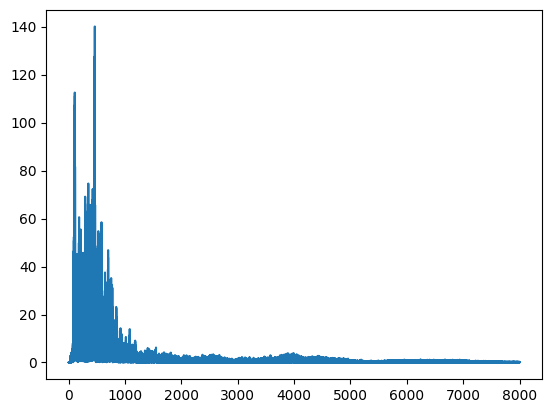

In [70]:
# first we're gonna look and see what we should try to filter
from scipy.fft import rfft, rfftfreq, irfft
import matplotlib.pyplot as plt

coefficients = rfft(data)
freqs = rfftfreq(n=len(data), d=1/rate)

plt.plot(freqs, abs(coefficients))

We're gonna try 3000, 5000, 7000

In [71]:
def low_pass_filter(wave, threshold, rate):
    coefficients = rfft(wave)
    freqs = rfftfreq(n= len(wave), d = 1/rate)


    mask = freqs > threshold
    coefficients[mask] = 0
    # same amount of sampels same length but just some elements are removed

    return irfft(coefficients, n=len(wave))
    # perform a rfft

In [72]:
low_pass1 = low_pass_filter(data, 7000, rate)
low_pass2 = low_pass_filter(data, 5000, rate)
low_pass3 = low_pass_filter(data, 3000,rate)


audio1 = Audio(data = low_pass1, rate = rate, normalize=False)
audio2 = Audio(data = low_pass2, rate = rate, normalize=False)
audio3 = Audio(data = low_pass3, rate = rate, normalize=False)

In [73]:
audio1

In [74]:
audio2

In [75]:
audio3

In [79]:
def plot_spectrum(data, rate):
    coefficients = rfft(data)
    freqs = rfftfreq(n=len(data), d=1/rate)
    plt.plot(freqs, abs(coefficients))

Now to actually test transcription results:

In [88]:
import pandas as pd
import collections

data = [low_pass1, low_pass2, low_pass3]
cutoffs = [7000, 5000, 3000]

results = collections.defaultdict(list)

for wave, freq in zip(data, cutoffs):
    transcription = transcribe(wave, rate)
    error = wp.wer(wp.normalize(reference), wp.normalize(transcription))
    results["Cutoff"].append(freq)
    results["Error"].append(error)

df = pd.DataFrame(results)
df

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,Cutoff,Error
0,7000,0.190476
1,5000,0.202381
2,3000,0.261905


Between 7000 and 5000 hz there isn't a big difference in how the audio sounds or the error. But when I lowered the cutoff to 3000 both the error and the distortion in the sound jumps.